# Tutorial 2 — Lipinski's Rule of Five & ADMET Profiling
**Author:** Himanshu Goel 

Lipinski's Ro5 predicts oral bioavailability — the most common drug delivery route. Violations don't disqualify a compound but warrant attention. ADMET (Absorption, Distribution, Metabolism, Excretion, Toxicity) profiling is the broader filter applied before investing in synthesis and testing.

In [ ]:
!pip install rdkit pandas numpy matplotlib -q

In [6]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def compute_admet(smiles, name=""):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw   = Descriptors.ExactMolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = Descriptors.TPSA(mol)
    rot  = rdMolDescriptors.CalcNumRotatableBonds(mol)
    rings= rdMolDescriptors.CalcNumRings(mol)
    arom = rdMolDescriptors.CalcNumAromaticRings(mol) 

    ro5_pass = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)
    veber    = (tpsa <= 140) and (rot <= 10)
    bbb_hint = (mw < 450) and (logp > 0) and (logp < 5) and (tpsa < 90) and (hbd <= 3)

    return {
        "Name": name, "MW": round(mw,1), "LogP": round(logp,2),
        "HBD": hbd, "HBA": hba, "TPSA": round(tpsa,1),
        "RotBonds": rot, "Rings": rings, "ArRings": arom,
        "Ro5": "PASS" if ro5_pass else "FAIL",
        "Veber": "PASS" if veber    else "FAIL",
        "BBB hint": "yes" if bbb_hint else "no",
    }

library = {
    "Aspirin":       "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":     "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Atorvastatin":  "CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O",
    "Paclitaxel":    "O=C(Nc1ccccc1)c1ccccc1OC(=O)[C@@H]2[C@@H](OC(C)(C)C(=O)O)CCC(=C)C2",
    "Metformin":     "CN(C)C(=N)NC(=N)N",
    "Caffeine":      "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Ciprofloxacin": "OC(=O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Sildenafil":    "CCCC1=NN(C)C(=O)c2[nH]cnc21",
    "Morphine":      "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",
    "Rapamycin":     "CCC(=O)O[C@@H]1C[C@H](CC[C@@H]([C@@H](CC[C@H]1OC)OC)C)OC",
}

df = pd.DataFrame([compute_admet(s, n) for n, s in library.items()])
print(df.to_string(index=False))

         Name    MW  LogP  HBD  HBA  TPSA  RotBonds  Rings  ArRings  Ro5 Veber BBB hint
      Aspirin 180.0  1.31    1    3  63.6         2      1        1 PASS  PASS      yes
    Ibuprofen 206.1  3.07    1    1  37.3         4      1        1 PASS  PASS      yes
 Atorvastatin 558.3  6.31    4    5 111.8        12      4        4 FAIL  FAIL       no
   Paclitaxel 437.2  4.45    2    5 101.9         7      3        2 PASS  PASS       no
    Metformin 129.1 -1.03    4    2  89.0         0      0        0 PASS  PASS       no
     Caffeine 194.1 -1.03    0    6  61.8         0      2        2 PASS  PASS       no
Ciprofloxacin 331.1  1.58    2    5  74.6         3      4        2 PASS  PASS      yes
   Sildenafil 192.1  0.61    1    4  63.6         2      2        2 PASS  PASS      yes
     Morphine 323.2  3.13    2    4  52.9         1      5        2 PASS  PASS      yes
    Rapamycin 316.2  2.95    0    5  54.0         5      1        0 PASS  PASS      yes


## Radar / spider chart for a selected compound

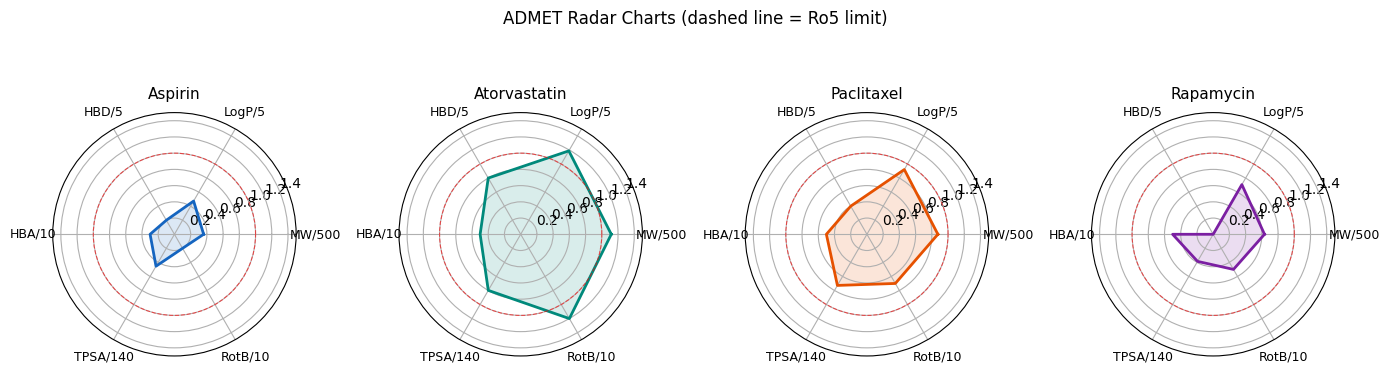

In [7]:
def radar_chart(row, ax, color):
    props  = ["MW/500", "LogP/5", "HBD/5", "HBA/10", "TPSA/140", "RotB/10"]
    values = [
        min(row["MW"]/500, 1.5),
        min((row["LogP"]+2)/7, 1.5),
        min(row["HBD"]/5, 1.5),
        min(row["HBA"]/10, 1.5),
        min(row["TPSA"]/140, 1.5),
        min(row["RotBonds"]/10, 1.5),
    ]
    n = len(props)
    angles = [i * 2 * np.pi / n for i in range(n)] + [0]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(props, size=9)
    ax.set_ylim(0, 1.5)
    ax.axhline(1.0, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(row["Name"], size=11, pad=10)

picks = ["Aspirin", "Atorvastatin", "Paclitaxel", "Rapamycin"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4), subplot_kw=dict(polar=True))
colors = ["#1565c0", "#00897b", "#e65100", "#7b1fa2"]
for ax, name, col in zip(axes, picks, colors):
    row = df[df["Name"] == name].iloc[0]
    radar_chart(row, ax, col)
plt.suptitle("ADMET Radar Charts (dashed line = Ro5 limit)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("admet_radar.png", dpi=150, bbox_inches='tight')
plt.show()

## Key takeaways
- **Ro5 PASS** doesn't guarantee oral bioavailability — it's a necessary but not sufficient condition
- Always combine Ro5 with Veber rules (TPSA ≤ 140, RotBonds ≤ 10) for better oral bioavailability prediction